# 📈 Chapter 4: Regression and Prediction
**Referensi Buku:** *Practical Statistics for Data Scientists* (Peter Bruce, Andrew Bruce, Peter Gedeck)

---
> **Topik:** Simple Linear Regression, Multiple Linear Regression, Categorical Variables, dan Model Diagnostics
---
## 1. Pendahuluan
Regresi adalah alat utama untuk memprediksi target numerik (kontinu). Bab ini membahas bagaimana membangun model yang tidak hanya akurat untuk prediksi, tetapi juga dapat diinterpretasikan untuk memahami pengaruh setiap fitur terhadap target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

%matplotlib inline
np.random.seed(42)

## 2. Simple Linear Regression
Model ini mencoba menyesuaikan garis $Y = b_0 + b_1X$. Kita akan mensimulasikan hubungan antara biaya iklan dan hasil penjualan.

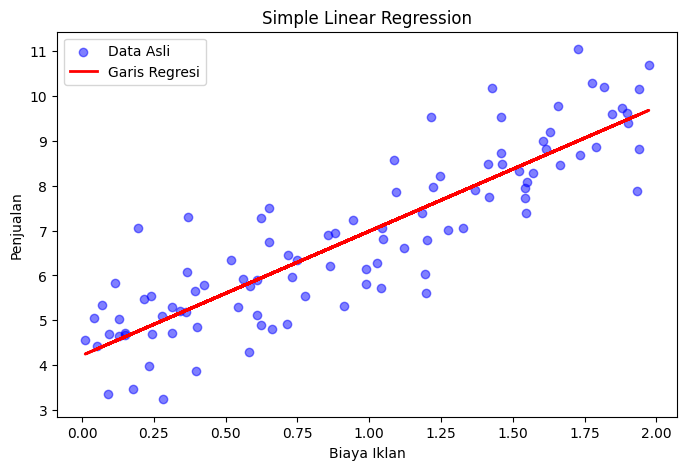

Intersep (b0): 4.22
Koefisien (b1): 2.77


In [2]:
# Simulasi data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data Asli')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Garis Regresi')
plt.title('Simple Linear Regression')
plt.xlabel('Biaya Iklan')
plt.ylabel('Penjualan')
plt.legend()
plt.show()

print(f"Intersep (b0): {model.intercept_[0]:.2f}")
print(f"Koefisien (b1): {model.coef_[0][0]:.2f}")

## 3. Multiple Linear Regression
Dalam dunia nyata, target sering dipengaruhi oleh banyak faktor. Kita menggunakan `statsmodels` untuk mendapatkan ringkasan statistik yang mendalam (seperti p-value untuk setiap koefisien).

In [3]:
# Membuat dataset dengan 3 prediktor
data = pd.DataFrame({
    'X1': np.random.rand(100),
    'X2': np.random.rand(100),
    'X3': np.random.rand(100),
    'Y': 10 + 2*np.random.rand(100) + 5*np.random.rand(100) - 3*np.random.rand(100)
})

X_mult = data[['X1', 'X2', 'X3']]
X_mult = sm.add_constant(X_mult) # Menambahkan konstanta/intersep
y_mult = data['Y']

model_mult = sm.OLS(y_mult, X_mult).fit()
print(model_mult.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.027
Method:                 Least Squares   F-statistic:                    0.1297
Date:                Fri, 10 Apr 2026   Prob (F-statistic):              0.942
Time:                        06:42:14   Log-Likelihood:                -191.28
No. Observations:                 100   AIC:                             390.6
Df Residuals:                      96   BIC:                             401.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.9078      0.543     21.923      0.0

## 4. Bekerja dengan Variabel Kategorikal
Regresi membutuhkan input angka. Jika kita memiliki data kategori (seperti jenis properti atau nama kota), kita harus melakukan *One-Hot Encoding*.

In [4]:
house_data = pd.DataFrame({
    'SqFt': [1500, 2000, 1200, 2400, 1800],
    'Type': ['House', 'Condo', 'House', 'Apartment', 'Condo'],
    'Price': [300000, 250000, 280000, 400000, 270000]
})

# Mengubah kategori menjadi dummy variables
house_encoded = pd.get_dummies(house_data, columns=['Type'], drop_first=True)
display(house_encoded)

,SqFt,Price,Type_Condo,Type_House
0,1500,300000,False,True
1,2000,250000,True,False
2,1200,280000,False,True
3,2400,400000,False,False
4,1800,270000,True,False


## 5. Diagnostik Regresi: Analisis Residual
Untuk melihat apakah model kita 'sehat', kita melihat pola dari sisa kesalahan (*residuals*). Jika residu tersebar acak di sekitar garis nol, maka model sudah cukup baik.

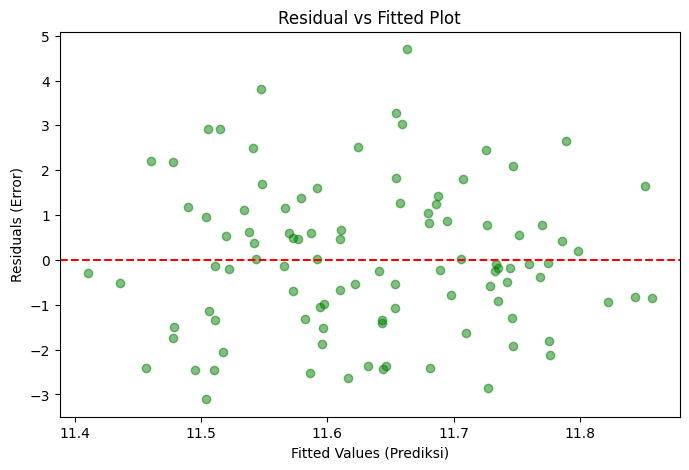

In [5]:
residuals = model_mult.resid
fitted = model_mult.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, color='green', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual vs Fitted Plot')
plt.xlabel('Fitted Values (Prediksi)')
plt.ylabel('Residuals (Error)')
plt.show()

## 6. Regresi Polinomial
Jika data memiliki tren melengkung, kita menambahkan fitur pangkat (misal $X^2$) untuk menangkap pola tersebut.

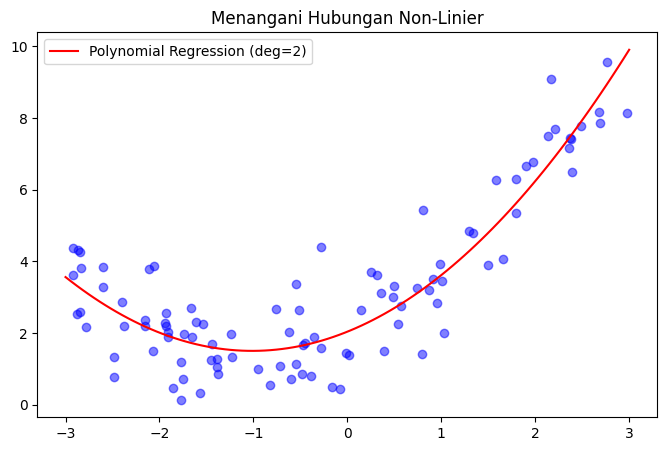

In [6]:
from sklearn.preprocessing import PolynomialFeatures

X_poly_data = 6 * np.random.rand(100, 1) - 3
y_poly_data = 0.5 * X_poly_data**2 + X_poly_data + 2 + np.random.randn(100, 1)

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X_poly_data)

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y_poly_data)

# Plot hasil
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(8, 5))
plt.scatter(X_poly_data, y_poly_data, color='blue', alpha=0.5)
plt.plot(X_new, y_new, color='red', label='Polynomial Regression (deg=2)')
plt.title('Menangani Hubungan Non-Linier')
plt.legend()
plt.show()